# research_report（研报盈利预测）全年推理结果分析

本 notebook 分析**2024 全年**研报推理结果（`artifacts/research_report_probs_forecast_stk_20240101_20241231.csv`，
单个文件，覆盖 `2024-01-01 ~ 2024-12-31`）。
推理由 `scripts/infer_research_report.py` 完成（文本 = `TITLE + 。 + CONTENT`，`max_length=512`，单卡 fp16），
本册只读产物做分析：逐月概况 / 概率分布 / 日度-个股聚合 / report_type·reliability 交叉 / 可视化。

**契约提醒（模型输出未确认项）：**
- 标签 `class_0/1` 语义未确认，**不要**命名为正面/负面/看多/看空；
- pooling 未确认（候选 `cls / pooler / masked_mean`），默认 `cls`（本册未重跑对比）；
- 结果为 fp16，与 fp32 概率约有 ~1e-3 差异；
- `report_type / reliability / organ_name / symbol` 为研报结构化字段，本册只做分布与交叉观察，**不臆断**其业务含义。

**与 social_text 分析的差异：**
- 本结果是**单个 CSV**（非 12 个月多文件 concat），且**无 `available_date` 列**；
- 以 `date`（= `CREATE_DATE` 的日期部分，研报发布日）作为日度聚合键，**未**做交易日对齐（研报周末/节假日亦会发布，见后）；
- 额外提供 `report_type / reliability / organ_name` 的结构化字段交叉分析。

In [1]:
# 环境与导入
%matplotlib inline
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = "/home/intern_fjq_2026/Projects/chinese-wwm-roberta"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

OUT_DIR = os.path.join(ROOT, "artifacts")

# 中文字体(避免 DejaVu 缺字/乱码)
plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei", "AR PL UMing CN", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("python:", sys.version.split()[0], "| numpy:", np.__version__, "| pandas:", pd.__version__)

python: 3.10.18 | numpy: 1.24.4 | pandas: 1.5.3


In [2]:
# 加载全年研报推理结果(单个 CSV)
CSV = os.path.join(OUT_DIR, "research_report_probs_forecast_stk_20240101_20241231.csv")
res = pd.read_csv(CSV, dtype={"class_0_prob": np.float32, "class_1_prob": np.float32,
                              "id": str, "symbol": str})
res["month"] = res["date"].str[:7]      # "2024-01"

print("加载完成: shape =", res.shape, "| 内存 ~%.1f MB" % (res.memory_usage(deep=True).sum()/1e6))
print("列:", list(res.columns))
res.head(3)

加载完成: shape = (273409, 13) | 内存 ~205.1 MB
列: ['class_0_prob', 'class_1_prob', 'id', 'symbol', 'stock_name', 'title', 'create_date', 'date', 'organ_name', 'report_type', 'reliability', 'source', 'month']


,class_0_prob,class_1_prob,id,symbol,stock_name,title,create_date,date,organ_name,report_type,reliability,source,month
0,0.726074,0.273926,3836861,000513,丽珠集团,医药生物：5大维度盘点医疗器械2023如何走过？2024有哪些关注？,2024-01-01 00:00:00,2024-01-01,国盛证券,21,5.0,research_report,2024-01
1,0.726074,0.273926,3836921,000538,云南白药,医药生物：5大维度盘点医疗器械2023如何走过？2024有哪些关注？,2024-01-01 00:00:00,2024-01-01,国盛证券,21,5.0,research_report,2024-01
2,0.669434,0.330322,3836490,000786,北新建材,北新建材：股权激励业绩考核目标较高，“一体两翼”超预期推进,2024-01-01 00:00:00,2024-01-01,广发证券,22,NaN,research_report,2024-01


In [3]:
# 结果体检: 行数 / NaN / 概率和 / 来源 / report_type / reliability / organ / 日期
print("逐月行数:")
print(res.groupby("month").size().rename("n_reports").to_string())
print()
print("NaN 数(class_0/1):", int(res[["class_0_prob", "class_1_prob"]].isna().sum().sum()))
print("reliability 缺失: %d (%.1f%%)" % (int(res["reliability"].isna().sum()), res["reliability"].isna().mean()*100))
s = res["class_0_prob"] + res["class_1_prob"]
print("概率和 max|sum-1|:", round(abs(s - 1).max(), 6))
print()
print("来源分布:")
print(res["source"].value_counts().to_string())
print()
print("report_type 分布(代码, 语义未确认):")
print(res["report_type"].value_counts().to_string())
print()
print("reliability 分布(大量缺失):")
print(res["reliability"].value_counts(dropna=False).to_string())
print()
print("organ_name: %d 家机构 | symbol: %d 只个股 | id 唯一: %d" % (res["organ_name"].nunique(), res["symbol"].nunique(), res["id"].nunique()))
print("organ_name top 10:")
print(res["organ_name"].astype(str).value_counts().head(10).to_string())
print()
print("日期覆盖: %s -> %s | 唯一日期 %d" % (res["date"].min(), res["date"].max(), res["date"].nunique()))
print("星期分布(0=周一..6=周日, 研报含周末发布):")
print(pd.to_datetime(res["date"]).dt.dayofweek.value_counts().sort_index().to_string())

逐月行数:
month
2024-01    15198
2024-02     9256
2024-03    21614
2024-04    51094
2024-05    24560
2024-06     8743
2024-07    12373
2024-08    42470
2024-09    22963
2024-10    33356
2024-11    23246
2024-12     8536

NaN 数(class_0/1): 0
reliability 缺失: 231665 (84.7%)
概率和 max|sum-1|: 0.000244

来源分布:
research_report    273409

report_type 分布(代码, 语义未确认):
25    202717
21     41756
22     16131
23     12502
26       213
24        90

reliability 分布(大量缺失):
NaN    231665
5.0     25582
9.0      7345
7.0      5566
8.0      3037
1.0       178
6.0        36

organ_name: 94 家机构 | symbol: 3422 只个股 | id 唯一: 273409
organ_name top 10:
国泰君安      11587
华泰证券      10621
申万宏源证券    10229
浙商证券       9791
东吴证券       9183
中金         8851
长江证券       8366
中信证券       8347
国信证券       8210
中信建投       8030

日期覆盖: 2024-01-01 -> 2024-12-31 | 唯一日期 366
星期分布(0=周一..6=周日, 研报含周末发布):


0    47180
1    47770
2    41655
3    41197
4    38927
5    19320
6    37360


In [4]:
# class_1_prob 分布: 整体 + 逐月
print("class_1_prob 整体分布:")
print(res["class_1_prob"].describe().round(4).to_string())
print()
mm = res.groupby("month")["class_1_prob"].agg(["mean", "median", "std", "count"])
print("逐月 class_1_prob:")
print(mm.round(4).to_string())

class_1_prob 整体分布:
count    273409.0000
mean          0.3287
std           0.0732
min           0.0732
25%           0.2849
50%           0.3342
75%           0.3733
max           0.6133

逐月 class_1_prob:
           mean  median     std  count
month                                 
2024-01  0.3108  0.3123  0.0807  15198
2024-02  0.3074  0.3010  0.0823   9256
2024-03  0.3348  0.3391  0.0765  21614
2024-04  0.3543  0.3513  0.0619  51094
2024-05  0.3278  0.3369  0.0739  24560
2024-06  0.2675  0.2605  0.0666   8743
2024-07  0.2965  0.2983  0.0706  12373
2024-08  0.3398  0.3401  0.0636  42470
2024-09  0.3246  0.3318  0.0739  22963
2024-10  0.3358  0.3386  0.0676  33356
2024-11  0.3253  0.3309  0.0739  23246
2024-12  0.2636  0.2542  0.0646   8536


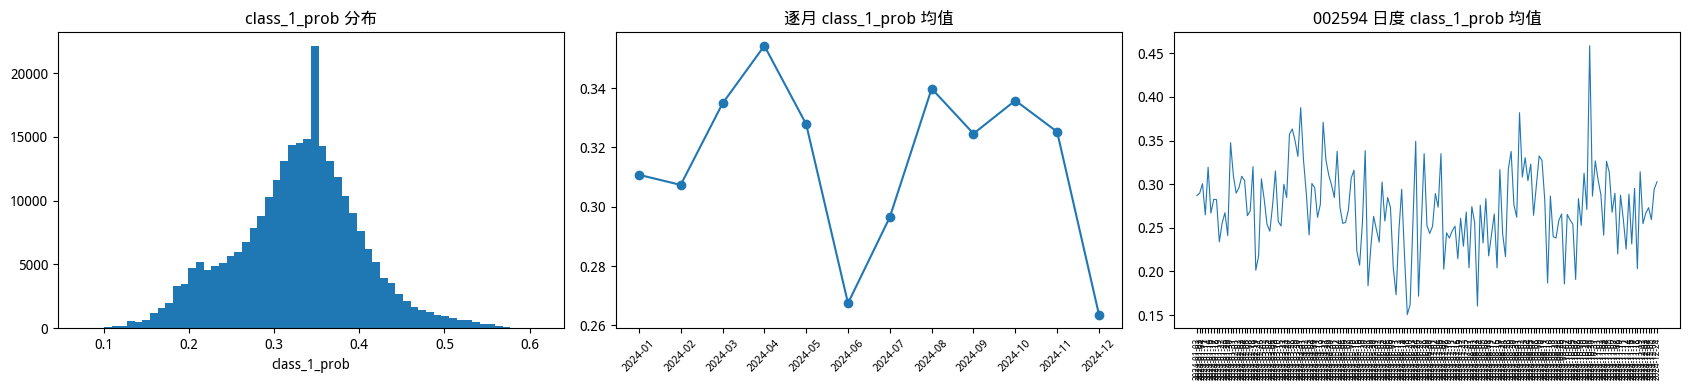

In [5]:
# 可视化: 直方图 / 逐月均值 / 样本个股日度时序
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# 1) 直方图(研报量 ~27 万, 直接全量)
axes[0].hist(res["class_1_prob"], bins=60)
axes[0].set_title("class_1_prob 分布")
axes[0].set_xlabel("class_1_prob")

# 2) 逐月 class_1_prob 均值
mm = res.groupby("month")["class_1_prob"].mean()
axes[1].plot(mm.index, mm.values, marker="o")
axes[1].set_title("逐月 class_1_prob 均值")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

# 3) 样本个股日度均值时序
top_sym = res["symbol"].value_counts().index[0]
d = (res[res["symbol"] == top_sym]
     .groupby("date")["class_1_prob"].mean().sort_index())
axes[2].plot(d.index.astype(str), d.values, lw=0.8)
axes[2].set_title(f"{top_sym} 日度 class_1_prob 均值")
axes[2].tick_params(axis="x", rotation=90, labelsize=6)
plt.tight_layout()
plt.show()

In [6]:
# 日度-个股情绪分数(全年聚合, 键=发布日 date) + 落盘
daily = (res.groupby(["date", "symbol"])["class_1_prob"]
         .agg(["mean", "median", "std", "count"]).reset_index())
daily.columns = ["date", "symbol", "sentiment_mean", "sentiment_median", "sentiment_std", "n_reports"]
daily = daily.sort_values(["date", "symbol"])
DAILY_PATH = os.path.join(OUT_DIR, "research_report_daily_2024.csv")
daily.to_csv(DAILY_PATH, index=False)
print(f"全年聚合: {daily.shape[0]} 行 (发布日 x 个股) -> {DAILY_PATH}")
print("每日每股票研报数分布(n_reports):")
print(daily["n_reports"].describe().round(3).to_string())
daily.head()

全年聚合: 63939 行 (发布日 x 个股) -> /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/research_report_daily_2024.csv
每日每股票研报数分布(n_reports):
count    63939.000
mean         4.276
std          4.031
min          1.000
25%          3.000
50%          3.000
75%          3.000
max         92.000


,date,symbol,sentiment_mean,sentiment_median,sentiment_std,n_reports
0,2024-01-01,000513,0.273926,0.273926,NaN,1
1,2024-01-01,000538,0.273926,0.273926,NaN,1
2,2024-01-01,000786,0.290975,0.299438,0.031999,18
3,2024-01-01,000858,0.276367,0.276367,0.000000,3
4,2024-01-01,000869,0.276367,0.276367,0.000000,3


---

## 附加：report_type / reliability 交叉分析（探索性）

研报结构化字段（`report_type` 为代码、`reliability` 疑似评级/可信度，均**未确认语义**）与
`class_1_prob` 的交叉，仅作探索性观察，不据此下因果/语义结论。

In [7]:
# report_type / reliability 与 class_1_prob 的交叉(探索性, 语义未确认)
print("report_type x class_1_prob:")
print(res.groupby("report_type")["class_1_prob"].agg(["mean", "median", "std", "count"]).round(4).to_string())
print()
print("reliability 是否缺失 x class_1_prob:")
print(res.assign(has_rel=res["reliability"].notna()).groupby("has_rel")["class_1_prob"]
      .agg(["mean", "median", "count"]).round(4).to_string())
print()
print("reliability (非缺失值) x class_1_prob:")
print(res[res["reliability"].notna()].groupby("reliability")["class_1_prob"]
      .agg(["mean", "median", "std", "count"]).round(4).to_string())
print()
print("reliability 缺失 与 report_type 的关联(交叉表):")
print(pd.crosstab(res["report_type"], res["reliability"].notna(),
                  rownames=["report_type"], colnames=["rel_present"]).to_string())

report_type x class_1_prob:
               mean  median     std   count
report_type                                
21           0.2549  0.2440  0.0686   41756
22           0.3266  0.3218  0.0648   16131
23           0.2847  0.2856  0.0483   12502
24           0.2886  0.2893  0.0588      90
25           0.3468  0.3459  0.0648  202717
26           0.2945  0.2991  0.0529     213

reliability 是否缺失 x class_1_prob:
           mean  median   count
has_rel                        
False    0.3420  0.3416  231665
True     0.2549  0.2440   41744

reliability (非缺失值) x class_1_prob:
               mean  median     std  count
reliability                               
1.0          0.1817  0.1736  0.0295    178
5.0          0.2393  0.2319  0.0605  25582
6.0          0.3194  0.3491  0.0540     36
7.0          0.2384  0.2288  0.0614   5566
8.0          0.2268  0.2183  0.0507   3037
9.0          0.3351  0.3491  0.0452   7345

reliability 缺失 与 report_type 的关联(交叉表):
rel_present   False  True 
report_type

---

## 结论与下一步

- 2024 全年研报推理结果已在本册完成：**逐月概况 / 概率分布 / 日度-个股聚合(`artifacts/research_report_daily_2024.csv`) / report_type·reliability 交叉 / 可视化**。
- 数据要点：共 27.3 万篇研报、3422 只个股、94 家机构；`reliability` 缺失 84.7%，且几乎只在 `report_type=21` 中有值。
- 已知限制：标签语义未确认、pooling 未确认（默认 `cls`）、fp16 概率 ~1e-3 差异、日度聚合以发布日 `date` 为键未做交易日对齐。
- 下一步候选：
  1. 用 `research_report_daily_2024.csv` 对齐 `artifacts/label_engineering/` 的**一致预期/修正标签**（`build_labels.py` 产物）做验证；
  2. 结合 `report_type/reliability/organ_name` 做机构分组下的信号稳定性检查；
  3. 与 `social_text_daily_2024.csv` 的日度情绪分数做交叉对比。